<a href="https://colab.research.google.com/github/saniyamaryjojo/aurora-visibility-neural-network-attempt/blob/main/aurora_visibility_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("seeauroratonight-destination-visibility-thresholds.csv")

In [3]:
df.head()

,slug,name,country,region,hemisphere,lat,lon,geomagnetic_lat,min_kp_index,timezone,...,visibility_mar,visibility_apr,visibility_may,visibility_jun,visibility_jul,visibility_aug,visibility_sep,visibility_oct,visibility_nov,visibility_dec
0,longyearbyen,Longyearbyen,Norway,Svalbard,N,78.22,15.65,75.3,0,Arctic/Longyearbyen,...,2,1,0,0,0,0,2,3,3,3
1,kangerlussuaq,Kangerlussuaq,Greenland,Greenland,N,67.01,-50.69,73.2,0,America/Nuuk,...,3,1,0,0,0,1,3,3,3,3
2,iqaluit,Iqaluit,Canada,Canada,N,63.75,-68.52,71.5,0,America/Iqaluit,...,3,1,0,0,0,1,3,3,3,3
3,nuuk,Nuuk,Greenland,Greenland,N,64.18,-51.69,70.5,0,America/Nuuk,...,3,1,0,0,0,1,3,3,3,3
4,churchill,Churchill,Canada,Canada,N,58.77,-94.17,68.6,0,America/Winnipeg,...,3,1,0,0,0,1,3,3,3,3


In [4]:
df.shape

(69, 24)

In [5]:
df.columns

Index(['slug', 'name', 'country', 'region', 'hemisphere', 'lat', 'lon',
       'geomagnetic_lat', 'min_kp_index', 'timezone', 'season', 'best_months',
       'visibility_jan', 'visibility_feb', 'visibility_mar', 'visibility_apr',
       'visibility_may', 'visibility_jun', 'visibility_jul', 'visibility_aug',
       'visibility_sep', 'visibility_oct', 'visibility_nov', 'visibility_dec'],
      dtype='object')

In [6]:
from sklearn.model_selection import train_test_split

In [8]:
X = df[["lat", "lon", "geomagnetic_lat", "min_kp_index"]]
X.head()

,lat,lon,geomagnetic_lat,min_kp_index
0,78.22,15.65,75.3,0
1,67.01,-50.69,73.2,0
2,63.75,-68.52,71.5,0
3,64.18,-51.69,70.5,0
4,58.77,-94.17,68.6,0


In [11]:
y = df["visibility_jan"]
y.head()


,visibility_jan
0,3
1,3
2,3
3,3
4,3


In [12]:
y.value_counts()

,count
visibility_jan,
3,60
0,9


In [13]:
for month in [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]:
    print(month)
    print(df[f"visibility_{month}"].value_counts())
    print()

jan
visibility_jan
3    60
0     9
Name: count, dtype: int64

feb
visibility_feb
3    60
1     9
Name: count, dtype: int64

mar
visibility_mar
3    59
2    10
Name: count, dtype: int64

apr
visibility_apr
1    39
2    30
Name: count, dtype: int64

may
visibility_may
0    39
1    21
3     9
Name: count, dtype: int64

jun
visibility_jun
0    60
3     9
Name: count, dtype: int64

jul
visibility_jul
0    60
3     9
Name: count, dtype: int64

aug
visibility_aug
1    38
2    30
0     1
Name: count, dtype: int64

sep
visibility_sep
3    59
2    10
Name: count, dtype: int64

oct
visibility_oct
3    60
1     9
Name: count, dtype: int64

nov
visibility_nov
3    60
0     9
Name: count, dtype: int64

dec
visibility_dec
3    60
0     9
Name: count, dtype: int64



In [15]:
y = df["visibility_apr"].map({1: 0, 2: 1})
y.value_counts()

,count
visibility_apr,
0,39
1,30


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (55, 4)
X_test: (14, 4)
y_train: (55,)
y_test: (14,)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
print(X_train.iloc[0])
print()
print(X_train_scaled[0])

lat                69.3
lon                17.5
geomagnetic_lat    66.4
min_kp_index        1.0
Name: 13, dtype: float64

[ 0.48271222  0.1727369   0.42785013 -0.49335324]


In [26]:
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_split=0.2
)


Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 390ms/step - accuracy: 0.7500 - loss: 0.5932 - val_accuracy: 0.6364 - val_loss: 0.6445
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7727 - loss: 0.5915 - val_accuracy: 0.6364 - val_loss: 0.6434
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7727 - loss: 0.5898 - val_accuracy: 0.6364 - val_loss: 0.6423
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7727 - loss: 0.5878 - val_accuracy: 0.6364 - val_loss: 0.6410
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7955 - loss: 0.5857 - val_accuracy: 0.6364 - val_loss: 0.6394
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7955 - loss: 0.5838 - val_accuracy: 0.6364 - val_loss: 0.6379
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7955 - loss: 0.5815 - val_accuracy: 0.6364 - val_loss: 0.6366
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7955 - loss: 0.5796 - val_accuracy: 0.6364 - val_loss: 0.63

In [29]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7857 - loss: 0.5604
Test loss: 0.5603718161582947
Test accuracy: 0.7857142686843872


In [30]:
predictions = model.predict(X_test_scaled)

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
[[0.5048506 ]
 [0.47814345]
 [0.6266862 ]
 [0.6369529 ]
 [0.79596066]
 [0.48713616]
 [0.5064395 ]
 [0.9981935 ]
 [0.5423621 ]
 [0.6347064 ]
 [0.47586226]
 [0.64531153]
 [0.4802503 ]
 [0.47630042]]


In [32]:
predicted_classes = (predictions >= 0.5).astype(int)
results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": predictions.flatten(),
    "Predicted": predicted_classes.flatten()
})

results

,Actual,Probability,Predicted
0,0,0.504851,1
1,0,0.478143,0
2,0,0.626686,1
3,1,0.636953,1
4,1,0.795961,1
5,0,0.487136,0
6,0,0.506440,1
7,1,0.998194,1
8,1,0.542362,1
9,1,0.634706,1


In [33]:
results = pd.DataFrame({
    "Location": df.loc[X_test.index, "name"].values,
    "Country": df.loc[X_test.index, "country"].values,
    "Latitude": X_test["lat"].values,
    "Geomagnetic Latitude": X_test["geomagnetic_lat"].values,
    "Min Kp": X_test["min_kp_index"].values,
    "Actual": y_test.values,
    "Probability": predictions.flatten(),
    "Predicted": predicted_classes.flatten()
})

results["Correct"] = results["Actual"] == results["Predicted"]

results

,Location,Country,Latitude,Geomagnetic Latitude,Min Kp,Actual,Probability,Predicted,Correct
0,Dawson City,Canada,64.06,65.5,1,0,0.504851,1,False
1,Kautokeino,Norway,69.01,65.8,1,0,0.478143,0,True
2,Bodø,Norway,67.28,64.6,2,0,0.626686,1,False
3,Gällivare,Sweden,67.13,64.2,2,1,0.636953,1,True
4,Kuusamo (Ruka),Finland,65.96,62.6,3,1,0.795961,1,True
5,Utsjoki,Finland,69.91,66.3,1,0,0.487136,0,True
6,Chena Hot Springs,United States,65.05,65.8,1,0,0.506440,1,False
7,Lake Tekapo,New Zealand,-44.00,-49.7,7,1,0.998194,1,True
8,Anchorage,United States,61.22,61.5,3,1,0.542362,1,True
9,Jokkmokk,Sweden,66.61,63.9,2,1,0.634706,1,True


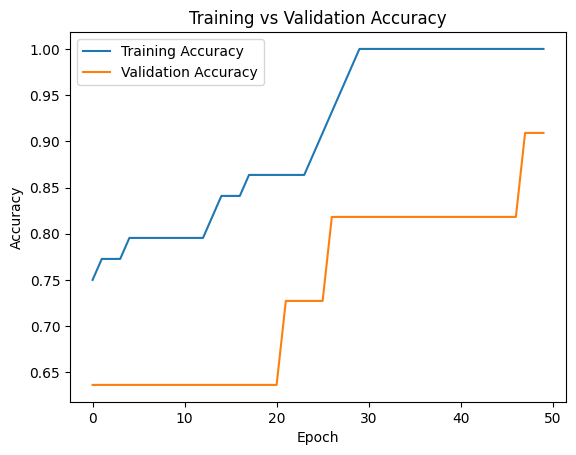

In [34]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

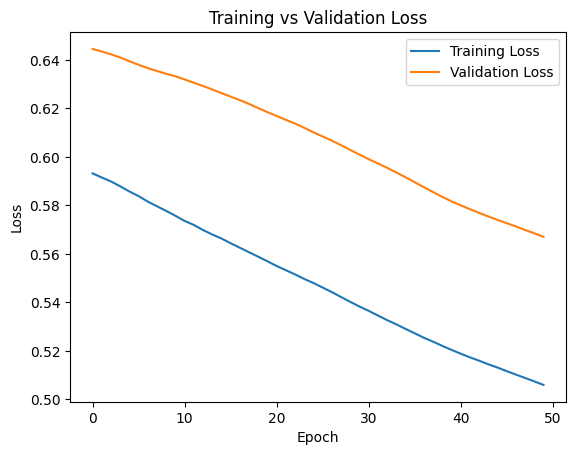

In [35]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_classes)

print(cm)

[[5 3]
 [0 6]]
